# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.estimator import EstimatorOptions, EstimatorV2 as Estimator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.providers.backend import BackendV2 as Backend
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity, SparsePauliOp
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

In [2]:
def prepare_ghz(n_qubits: int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_estimator(mode):
    ## Estimator with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    estimator_options = EstimatorOptions(default_shots=4096, seed_estimator=42069, dynamical_decoupling={"enable": False},twirling={"enable_gates": False, "enable_measure": False},resilience_level=0, resilience={"measure_mitigation":False, "zne_mitigation":False, "pec_mitigation":False}) 

    estimator = Estimator(mode=mode, options=estimator_options)
    return estimator

def noiseless_estimator_pub(actual_qubits:int, isa_circuit:QuantumCircuit, pauli="Z"):

    ## Creating Pauli Op and mapping the operator to correct qubits. Note: this can be avoided as our observable is "ZZ..Z" but still going with the procedure
    isa_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)

    pub = (isa_circuit, isa_observable)

    return pub


def estimator_pub(isa_circuit:QuantumCircuit, isa_dd_xx_circuit:QuantumCircuit, isa_dd_xpxm_circuit:QuantumCircuit, pauli="Z"):
    ## NOTE: isa_circuit and isa_dd_circuit must have the same no. of "actual qubit"
    ## Creating Pauli Op and mapping the operator to correct qubits. 
    actual_qubits = len(isa_circuit.layout.final_index_layout())
    isa_observable    = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)
    isa_dd_xx_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_dd_xx_circuit.layout)
    isa_dd_xpxm_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_dd_xpxm_circuit.layout)
    

    pub = [(isa_circuit, isa_observable), (isa_dd_xx_circuit, isa_dd_xx_observable), (isa_dd_xpxm_circuit, isa_dd_xpxm_observable)]

    return pub





def pm_for_backend(bknd: Backend, opt_level, seed=42069):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    return pm


def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm


def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit


def execute_on_hardware(bknd :Backend , estimator_pub):
    ## Batch mode execution of quantum circuits on hardware
    
    with Batch(backend=bknd) as batch:
        estimator = naked_estimator(mode=batch)
        job = estimator.run(estimator_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service: QiskitRuntimeService, id: str):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

## Circuit generation and transpilation

In [3]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_echo_ghz_with_xs(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bdb3141d0>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bdc52d890>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bdb316e90>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bdb315710>}

In [4]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

fez = service.backend("ibm_fez")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(fez, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD

dd_xpxm_pm = prepare_dd_pm(fez, seq="XpXm", scheduling_method="alap")

dd_xx_pm = prepare_dd_pm(fez, seq="XX", scheduling_method="alap")


isa_dd_xpxm_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xpxm_pm, fez) for i in range(7, 11)}

isa_dd_xx_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xx_pm, fez) for i in range(7, 11)}


print(isa_dict)



management.get:WARNING:2025-11-30 04:37:24,090: Loading saved account: qamp-2025


{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x773bda747d50>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x773bda879f90>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x773bda7e39d0>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x773bda748690>}


In [5]:
isa_dict["7"].draw(fold=-1)

global phase: π/2
           ┌─────────┐┌────┐ ┌───────┐                                            ┌────┐┌─────────┐                                                             ░  ░                                                                                                  ┌─────────┐   ┌────┐  ┌───────┐      ┌────┐  ┌─────────┐                                                                                ░ ┌───┐ ░          ┌─┐         
q_3 -> 123 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├─────────┤├────┤ ├───────┤                        ┌────┐┌─────────┐ │ └────┘└─────────┘ │                                                           ░  ░                                                                                                │ └─────────┘   └────┘  └───────┘ │ ┌──┴────┴─┐└──┬────┬─┘┌───────┐      ┌────┐  ┌─────────┐                                              ░ ├───┤ ░       ┌─┐└╥┘         
q_2 -> 124 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────┼───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├──────────────────────────────────────────────░─┤ X ├─░───────┤M├─╫──────────
           ├─────────┤├────┤ ├───────┤    ┌────┐┌─────────┐ │ └────┘└─────────┘                     │                                                           ░  ░                                                                                                │                                   └─────────┘   └────┘  └───────┘ │ ┌──┴────┴─┐└──┬────┬─┘┌───────┐      ┌────┐  ┌─────────┐            ░ ├───┤ ░    ┌─┐└╥┘ ║          
q_1 -> 125 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────┼───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─■────┤ √X ├──┤ Rz(π/2) ├────────────░─┤ X ├─░────┤M├─╫──╫──────────
           ├─────────┤├────┤┌┴───────┴┐ │ └────┘└─────────┘                                         │                                                           ░  ░                                                                                                │                                                                     └─────────┘   └────┘  └───────┘ │ ┌──┴────┴─┐└──┬────┬─┘┌─────────┐ ░ ├───┤ ░ ┌─┐└╥┘ ║  ║          
q_0 -> 126 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────░──░────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├─╫──╫──╫──────────
           ├─────────┤├────┤└┬───────┬┘                                                             │ ┌────┐┌─────────┐                                         ░  ░                                                                ┌─────────┐   ┌────┐  ┌───────┐ │    ┌────┐  ┌─────────┐                                                                                └─────────┘   └────┘  └─────────┘ ░ ├───┤ ░ └╥┘ ║  ║  ║ ┌─┐      
q_4 -> 136 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz

In [6]:
isa_dd_xx_dict["7"].draw(fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                                                      ┌────┐        ┌─────────┐                       ┌───────────────┐      ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐                                                 ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                               ┌─────────┐   ┌────┐    ┌───────┐          ┌──────────────┐┌───┐ ┌───────────────┐┌───┐┌──────────────┐┌────┐  ┌─────────┐                                               ░ ┌───┐ ░          ┌─┐         
q_3 -> 123 ┤ Delay(46[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├─────────────────────■─┤ Delay(10[dt]) ├──────┤ X ├──────┤ Delay(20[dt]) ├─────┤ X ├──────┤ Delay(10[dt]) ├─────────────────────────────────────────────────░──░─┤ Delay(10[dt]) ├┤ X ├─┤ Delay(20[dt]) ├┤ X ├┤ Delay(10[dt]) ├─────────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■───┤ Delay(8[dt]) ├┤ X ├─┤ Delay(18[dt]) ├┤ X ├┤ Delay(8[dt]) ├┤ √X ├──┤ Rz(π/2) ├───────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                   ┌────┐        ┌─────────┐           │        ┌─────┴────┴────┐   └──┬───┬──┘   ┌───────────────┐ │ └─────┬───┬─────┘┌─────┴───┴─────┐└───────────────┘     └───┘      └───────────────┘                                                 ░  ░ ├───────────────┤├───┤ ├───────────────┤├───┤├───────────────┤                                                                         │     └─────────┘   └────┘    └───────┘      │   └─┬─────────┬──┘├───┴┐└───┬───────┬───┘└───┘├──────────────┤├───┬┘┌─┴─────────┴──┐┌───┐┌──────────────┐   ┌────┐  ┌─────────┐ ░ ├───┤ ░       ┌─┐└╥┘         
q_2 -> 124 ┤ Delay(23[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(15[dt]) ├──────┤ X ├──────┤ Delay(33[dt]) ├─┼───────┤ X ├──────┤ Delay(15[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(15[dt]) ├┤ X ├─┤ Delay(33[dt]) ├┤ X ├┤ Delay(15[dt]) ├─────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(2[dt]) ├┤ X ├─┤ Delay(7[dt]) ├┤ X ├┤ Delay(2[dt]) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░───────┤M├─╫──────────
           └──┬─────────┬──┘ └──┬────┬─┘ ┌─┴────┴┐ └───────┘      ┌────┐     ┌─────────┐        │        ┌─────┴────┴────┐   └──┬───┬──┘   ┌───────────────┐└─────┬───┬─────┘┌─────┴───┴─────┐└───────────────┘ │       └───┘      └───────────────┘                                                                                                   ░  ░ ├───────────────┤├───┤ ├───────────────┤├───┤├───────────────┤                                                                         │                                                  └─────────┘   └────┘    └───────┘      │  └─┬─────────┬──┘├───┴┐└──┬───────┬───┘└───┘└────┬────┬────┘┌──┴────┴─┐└─────────┘ ░ ├───┤ ░    ┌─┐└╥┘ ║          
q_1 -> 125 ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├─────■──────────┤ √X ├─────┤ Rz(π/2) ├────────■────────┤ Delay(21[dt]) ├──────┤ X ├──────┤ Delay(44[dt]) ├──────┤ X ├──────┤ Delay(21[dt]) ├──────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(21[dt]) ├┤ X ├─┤ Delay(44[dt]) ├┤ X ├┤ Delay(21[dt]) ├─────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────

In [7]:
isa_dd_xpxm_dict["7"].draw(fold=-1)

global phase: π/2
           ┌───────────────┐ ┌─────────┐   ┌────┐  ┌───────┐                                                                                                      ┌────┐        ┌─────────┐                       ┌───────────────┐      ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐                                                 ░  ░ ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐                                                                               ┌─────────┐   ┌────┐    ┌───────┐          ┌──────────────┐┌───┐ ┌───────────────┐┌───┐┌──────────────┐┌────┐  ┌─────────┐                                               ░ ┌───┐ ░          ┌─┐         
q_3 -> 123 ┤ Delay(46[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├─────────────────────■─┤ Delay(10[dt]) ├──────┤ X ├──────┤ Delay(20[dt]) ├─────┤ X ├──────┤ Delay(10[dt]) ├─────────────────────────────────────────────────░──░─┤ Delay(10[dt]) ├┤ X ├─┤ Delay(20[dt]) ├┤ X ├┤ Delay(10[dt]) ├─────────────────────────────────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■───┤ Delay(8[dt]) ├┤ X ├─┤ Delay(18[dt]) ├┤ X ├┤ Delay(8[dt]) ├┤ √X ├──┤ Rz(π/2) ├───────────────────────────────────────────────░─┤ X ├─░──────────┤M├─────────
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                   ┌────┐        ┌─────────┐           │        ┌─────┴────┴────┐   └──┬───┬──┘   ┌───────────────┐ │ └─────┬───┬─────┘┌─────┴───┴─────┐└───────────────┘     └───┘      └───────────────┘                                                 ░  ░ ├───────────────┤├───┤ ├───────────────┤├───┤├───────────────┤                                                                         │     └─────────┘   └────┘    └───────┘      │   └─┬─────────┬──┘├───┴┐└───┬───────┬───┘└───┘├──────────────┤├───┬┘┌─┴─────────┴──┐┌───┐┌──────────────┐   ┌────┐  ┌─────────┐ ░ ├───┤ ░       ┌─┐└╥┘         
q_2 -> 124 ┤ Delay(23[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├────────────────────────────────────■──────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(15[dt]) ├──────┤ X ├──────┤ Delay(33[dt]) ├─┼───────┤ X ├──────┤ Delay(15[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(15[dt]) ├┤ X ├─┤ Delay(33[dt]) ├┤ X ├┤ Delay(15[dt]) ├─────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────■─────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├──────■──┤ Delay(2[dt]) ├┤ X ├─┤ Delay(7[dt]) ├┤ X ├┤ Delay(2[dt]) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░───────┤M├─╫──────────
           └──┬─────────┬──┘ └──┬────┬─┘ ┌─┴────┴┐ └───────┘      ┌────┐     ┌─────────┐        │        ┌─────┴────┴────┐   └──┬───┬──┘   ┌───────────────┐└─────┬───┬─────┘┌─────┴───┴─────┐└───────────────┘ │       └───┘      └───────────────┘                                                                                                   ░  ░ ├───────────────┤├───┤ ├───────────────┤├───┤├───────────────┤                                                                         │                                                  └─────────┘   └────┘    └───────┘      │  └─┬─────────┬──┘├───┴┐└──┬───────┬───┘└───┘└────┬────┬────┘┌──┴────┴─┐└─────────┘ ░ ├───┤ ░    ┌─┐└╥┘ ║          
q_1 -> 125 ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├─────■──────────┤ √X ├─────┤ Rz(π/2) ├────────■────────┤ Delay(21[dt]) ├──────┤ X ├──────┤ Delay(44[dt]) ├──────┤ X ├──────┤ Delay(21[dt]) ├──────────────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──░─┤ Delay(21[dt]) ├┤ X ├─┤ Delay(44[dt]) ├┤ X ├┤ Delay(21[dt]) ├─────────────────────────────────────────────────────────────────────────┼────────────────────────────────────────────────

In [8]:
# isa_dict["7"]
actual_qubits = isa_dict["7"].layout.final_index_layout()
actual_qubits

[126, 125, 124, 123, 136, 143, 142]

In [9]:
## PUBs for noiseless simulation
noiseless_pub_list = [noiseless_estimator_pub(i, isa_dict[f"{i}"]) for i in range(7, 11)]
noiseless_pub_list

[(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda747d50>,
  SparsePauliOp(['IIIIIIIIIIIIZZIIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda879f90>,
  SparsePauliOp(['IIIIIIIIIIIIZZZIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda7e39d0>,
  SparsePauliOp(['IIIIIIIIZZZZZIIIIIZZIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda748690>,
  SparsePauliOp(['IIIIIIIIIIIIZZIIIIIZIIIIIIIIIIZZZIIIIIZIIIIIIIIIIIZZZIIIIIIIIIIIIIIIIII

In [10]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()


with Batch(backend=noiseless_backend) as batch:
    noiseless_estimator = AerEstimator()
    noiseless_estimator.options.run_options={"shots":4096}
    noiseless_job = noiseless_estimator.run(noiseless_pub_list)
    noiseless_result = noiseless_job.result()


In [11]:
simulated_est_data = {f"{i+7}":noiseless_result[i].data for i in range(0,4)}
print(simulated_est_data['7'].evs , simulated_est_data['7'].stds)
print(simulated_est_data['8'].evs , simulated_est_data['8'].stds)
print(simulated_est_data['9'].evs , simulated_est_data['9'].stds)
print(simulated_est_data['10'].evs, simulated_est_data['10'].stds)

-1.0 0.0
1.0 0.0
-1.0 0.0
1.0 0.0


In [12]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":estimator_pub(isa_circuit=isa_dict[f"{i}"], isa_dd_xx_circuit=isa_dd_xx_dict[f"{i}"], isa_dd_xpxm_circuit=isa_dd_xpxm_dict[f"{i}"]) for i in range(7, 11)}
pub_hardware_dict

{'7': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda747d50>,
   SparsePauliOp(['IIIIIIIIIIIIZZIIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda771490>,
   SparsePauliOp(['IIIIIIIIIIIIZZIIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda778390>,
   SparsePauliOp(['IIIIIIIIIIIIZZIIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j]))],
 '8': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x773bda879f90>,
   SparsePauliOp(['IIIIIIIIIIIIZZZIIIIZIIIIIIIIIZZZZIIIIIIIIIIIIIIII

In [13]:
## Simulate on Aer Simulator

noisy_backend = AerSimulator()

noise_model = NoiseModel.from_backend(fez)
noisy_result = {}
for i in range(7, 11):
    with Batch(backend=noisy_backend) as batch:
        noisy_estimator = AerEstimator()
        noiseless_estimator.options.backend_options={"noise_model":noise_model}
        noisy_estimator.options.run_options={"shots":4096}
        noisy_job = noisy_estimator.run(pub_hardware_dict[f"{i}"])
        noisy_result[f"{i}"] = (noisy_job.result()[0].data.evs, noisy_job.result()[0].data.stds, noisy_job.result()[1].data.evs, noisy_job.result()[1].data.stds)



In [14]:
noisy_result

{'7': (array(-1.), array(0.), array(-1.), array(0.)),
 '8': (array(1.), array(0.), array(1.), array(0.)),
 '9': (array(-1.), array(0.), array(-1.), array(0.)),
 '10': (array(1.), array(0.), array(1.), array(0.))}

---
---
---

# Hardware Execution Cell. Do not run unless required

In [ ]:
## Executing experiments with iterations = 5. Total circuit to run = 3*5 = 15
# hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(fez, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 5)}

d4lnpvh0i6jc73dg05f0
d4lnq090i6jc73dg05gg
d4lnq0qv0j9c73e5h700
d4lnq1d74pkc7388755g
d4lnq1t74pkc7388756g
d4lnq290i6jc73dg05jg
d4lnq2qv0j9c73e5h730
d4lnq3c3tdfc73dploo0
d4lnq3qv0j9c73e5h740
d4lnq490i6jc73dg05lg
d4lnq4h0i6jc73dg05m0
d4lnq5574pkc738875ag
d4lnq5iv0j9c73e5h76g
d4lnq62v0j9c73e5h780
d4lnq6k3tdfc73dplotg
d4lnq6s3tdfc73dploug
d4lnq790i6jc73dg05s0
d4lnq7s3tdfc73dplp00
d4lnq8c3tdfc73dplp10
d4lnq8qv0j9c73e5h7bg


In [16]:
hardware_job_dict

{'0': {'7': 'd4lnpvh0i6jc73dg05f0',
  '8': 'd4lnq090i6jc73dg05gg',
  '9': 'd4lnq0qv0j9c73e5h700',
  '10': 'd4lnq1d74pkc7388755g'},
 '1': {'7': 'd4lnq1t74pkc7388756g',
  '8': 'd4lnq290i6jc73dg05jg',
  '9': 'd4lnq2qv0j9c73e5h730',
  '10': 'd4lnq3c3tdfc73dploo0'},
 '2': {'7': 'd4lnq3qv0j9c73e5h740',
  '8': 'd4lnq490i6jc73dg05lg',
  '9': 'd4lnq4h0i6jc73dg05m0',
  '10': 'd4lnq5574pkc738875ag'},
 '3': {'7': 'd4lnq5iv0j9c73e5h76g',
  '8': 'd4lnq62v0j9c73e5h780',
  '9': 'd4lnq6k3tdfc73dplotg',
  '10': 'd4lnq6s3tdfc73dploug'},
 '4': {'7': 'd4lnq790i6jc73dg05s0',
  '8': 'd4lnq7s3tdfc73dplp00',
  '9': 'd4lnq8c3tdfc73dplp10',
  '10': 'd4lnq8qv0j9c73e5h7bg'}}

---
---
---

# Above are the job-ids of experiments. Used these to get the Result Objects. 

In [1]:
import pandas as pd
from qiskit_ibm_runtime import QiskitRuntimeService

hardware_job_dict={'0': {'7': 'd4lnpvh0i6jc73dg05f0',
  '8': 'd4lnq090i6jc73dg05gg',
  '9': 'd4lnq0qv0j9c73e5h700',
  '10': 'd4lnq1d74pkc7388755g'},
 '1': {'7': 'd4lnq1t74pkc7388756g',
  '8': 'd4lnq290i6jc73dg05jg',
  '9': 'd4lnq2qv0j9c73e5h730',
  '10': 'd4lnq3c3tdfc73dploo0'},
 '2': {'7': 'd4lnq3qv0j9c73e5h740',
  '8': 'd4lnq490i6jc73dg05lg',
  '9': 'd4lnq4h0i6jc73dg05m0',
  '10': 'd4lnq5574pkc738875ag'},
 '3': {'7': 'd4lnq5iv0j9c73e5h76g',
  '8': 'd4lnq62v0j9c73e5h780',
  '9': 'd4lnq6k3tdfc73dplotg',
  '10': 'd4lnq6s3tdfc73dploug'},
 '4': {'7': 'd4lnq790i6jc73dg05s0',
  '8': 'd4lnq7s3tdfc73dplp00',
  '9': 'd4lnq8c3tdfc73dplp10',
  '10': 'd4lnq8qv0j9c73e5h7bg'}}


In [2]:
hardware_job_dict["0"]["7"]

'd4lnpvh0i6jc73dg05f0'

In [3]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-30 04:57:29,792: Loading saved account: qamp-2025


In [4]:
job = service.job("d4ln5l43tdfc73dpl4sg")
job.result()[0].metadata['shots']


4096

In [5]:

def store_estimator_data(service, job_dict):
    #           0         1       2        3         4           5           6           7           8              9
    # Index iteration | job_id | Qubit | shots | no_dd_evs | no_dd_std | dd_xx_evs | dd_xx_std | dd_xpxm_evs | dd_xpxm_std |
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "no_dd_evs", "no_dd_std", "dd_xx_evs", "dd_xx_std", "dd_xpxm_evs", "dd_xpxm_std"]

    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            shots = result[0].metadata["shots"]
            data_list.append(shots)

            data_list.append(result[0].data.evs)

            data_list.append(result[0].data.stds)

            data_list.append(result[1].data.evs)

            data_list.append(result[1].data.stds)
            
            data_list.append(result[2].data.evs)

            data_list.append(result[2].data.stds)
        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [6]:
experiment_results = store_estimator_data(service, hardware_job_dict)

In [7]:
## Save data to .csv

experiment_results.to_csv("GHZ-Echo-on-hardware-estimator.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [8]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [9]:

df = pd.read_csv("GHZ-Echo-on-hardware-estimator.csv")
df


,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
0,0,d4lnpvh0i6jc73dg05f0,7,4096,-0.703613,0.011103,-0.708984,0.011019,-0.696289,0.011215
1,0,d4lnq090i6jc73dg05gg,8,4096,0.626465,0.012179,0.655273,0.011803,0.638184,0.012029
2,0,d4lnq0qv0j9c73e5h700,9,4096,-0.571289,0.012824,-0.598633,0.012516,-0.605469,0.012435
3,0,d4lnq1d74pkc7388755g,10,4096,0.521973,0.013328,0.567383,0.012866,0.552246,0.013026
4,1,d4lnq1t74pkc7388756g,7,4096,-0.696289,0.011215,-0.681152,0.011440,-0.680176,0.011454
5,1,d4lnq290i6jc73dg05jg,8,4096,0.638672,0.012023,0.637207,0.012042,0.641113,0.011991
6,1,d4lnq2qv0j9c73e5h730,9,4096,-0.548828,0.013061,-0.606934,0.012418,-0.585449,0.012667
7,1,d4lnq3c3tdfc73dploo0,10,4096,0.546387,0.013086,0.542480,0.013126,0.543457,0.013116
8,2,d4lnq3qv0j9c73e5h740,7,4096,-0.697754,0.011193,-0.677246,0.011496,-0.664062,0.011682
9,2,d4lnq490i6jc73dg05lg,8,4096,0.634766,0.012074,0.648438,0.011895,0.642090,0.011979


In [10]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]


In [16]:
qubit_7

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
0,0,d4lnpvh0i6jc73dg05f0,7,4096,-0.703613,0.011103,-0.708984,0.011019,-0.696289,0.011215
4,1,d4lnq1t74pkc7388756g,7,4096,-0.696289,0.011215,-0.681152,0.011440,-0.680176,0.011454
8,2,d4lnq3qv0j9c73e5h740,7,4096,-0.697754,0.011193,-0.677246,0.011496,-0.664062,0.011682
12,3,d4lnq5iv0j9c73e5h76g,7,4096,-0.684570,0.011390,-0.663574,0.011689,-0.697266,0.011200
16,4,d4lnq790i6jc73dg05s0,7,4096,-0.708496,0.011027,-0.691895,0.011281,-0.672852,0.011559


In [17]:
qubit_8

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
1,0,d4lnq090i6jc73dg05gg,8,4096,0.626465,0.012179,0.655273,0.011803,0.638184,0.012029
5,1,d4lnq290i6jc73dg05jg,8,4096,0.638672,0.012023,0.637207,0.012042,0.641113,0.011991
9,2,d4lnq490i6jc73dg05lg,8,4096,0.634766,0.012074,0.648438,0.011895,0.642090,0.011979
13,3,d4lnq62v0j9c73e5h780,8,4096,0.633789,0.012086,0.665039,0.011669,0.623047,0.012222
17,4,d4lnq7s3tdfc73dplp00,8,4096,0.641602,0.011985,0.649902,0.011875,0.652832,0.011836


In [18]:
qubit_9

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
2,0,d4lnq0qv0j9c73e5h700,9,4096,-0.571289,0.012824,-0.598633,0.012516,-0.605469,0.012435
6,1,d4lnq2qv0j9c73e5h730,9,4096,-0.548828,0.013061,-0.606934,0.012418,-0.585449,0.012667
10,2,d4lnq4h0i6jc73dg05m0,9,4096,-0.571777,0.012819,-0.598145,0.012522,-0.592285,0.012590
14,3,d4lnq6k3tdfc73dplotg,9,4096,-0.577637,0.012755,-0.605957,0.012430,-0.605469,0.012435
18,4,d4lnq8c3tdfc73dplp10,9,4096,-0.571289,0.012824,-0.576172,0.012771,-0.576660,0.012765


In [19]:
qubit_10

,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
3,0,d4lnq1d74pkc7388755g,10,4096,0.521973,0.013328,0.567383,0.012866,0.552246,0.013026
7,1,d4lnq3c3tdfc73dploo0,10,4096,0.546387,0.013086,0.542480,0.013126,0.543457,0.013116
11,2,d4lnq5574pkc738875ag,10,4096,0.512695,0.013415,0.544434,0.013106,0.548828,0.013061
15,3,d4lnq6s3tdfc73dploug,10,4096,0.510254,0.013438,0.540039,0.013151,0.530762,0.013243
19,4,d4lnq8qv0j9c73e5h7bg,10,4096,0.484863,0.013665,0.524902,0.013299,0.505859,0.013478


In [ ]:
qubit_9

In [11]:
qubit_7.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,7.0,4096.0,-0.698145,0.011185,-0.684570,0.011385,-0.682129,0.011422
std,1.581139,0.0,0.0,0.009013,0.000137,0.016999,0.000251,0.014542,0.000212
min,0.000000,7.0,4096.0,-0.708496,0.011027,-0.708984,0.011019,-0.697266,0.011200
25%,1.000000,7.0,4096.0,-0.703613,0.011103,-0.691895,0.011281,-0.696289,0.011215
50%,2.000000,7.0,4096.0,-0.697754,0.011193,-0.681152,0.011440,-0.680176,0.011454
75%,3.000000,7.0,4096.0,-0.696289,0.011215,-0.677246,0.011496,-0.672852,0.011559
max,4.000000,7.0,4096.0,-0.684570,0.011390,-0.663574,0.011689,-0.664062,0.011682


In [12]:
qubit_8.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,8.0,4096.0,0.635059,0.012069,0.651172,0.011857,0.639453,0.012011
std,1.581139,0.0,0.0,0.005732,0.000073,0.010164,0.000136,0.010718,0.000139
min,0.000000,8.0,4096.0,0.626465,0.011985,0.637207,0.011669,0.623047,0.011836
25%,1.000000,8.0,4096.0,0.633789,0.012023,0.648438,0.011803,0.638184,0.011979
50%,2.000000,8.0,4096.0,0.634766,0.012074,0.649902,0.011875,0.641113,0.011991
75%,3.000000,8.0,4096.0,0.638672,0.012086,0.655273,0.011895,0.642090,0.012029
max,4.000000,8.0,4096.0,0.641602,0.012179,0.665039,0.012042,0.652832,0.012222


In [13]:
qubit_9.describe()


,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,9.0,4096.0,-0.568164,0.012857,-0.597168,0.012531,-0.593066,0.012579
std,1.581139,0.0,0.0,0.011138,0.000118,0.012415,0.000142,0.012604,0.000145
min,0.000000,9.0,4096.0,-0.577637,0.012755,-0.606934,0.012418,-0.605469,0.012435
25%,1.000000,9.0,4096.0,-0.571777,0.012819,-0.605957,0.012430,-0.605469,0.012435
50%,2.000000,9.0,4096.0,-0.571289,0.012824,-0.598633,0.012516,-0.592285,0.012590
75%,3.000000,9.0,4096.0,-0.571289,0.012824,-0.598145,0.012522,-0.585449,0.012667
max,4.000000,9.0,4096.0,-0.548828,0.013061,-0.576172,0.012771,-0.576660,0.012765


In [14]:
qubit_10.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_xx_evs,dd_xx_std,dd_xpxm_evs,dd_xpxm_std
count,5.000000,5.0,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,10.0,4096.0,0.515234,0.013386,0.543848,0.013110,0.536230,0.013185
std,1.581139,0.0,0.0,0.022190,0.000209,0.015244,0.000156,0.018840,0.000183
min,0.000000,10.0,4096.0,0.484863,0.013086,0.524902,0.012866,0.505859,0.013026
25%,1.000000,10.0,4096.0,0.510254,0.013328,0.540039,0.013106,0.530762,0.013061
50%,2.000000,10.0,4096.0,0.512695,0.013415,0.542480,0.013126,0.543457,0.013116
75%,3.000000,10.0,4096.0,0.521973,0.013438,0.544434,0.013151,0.548828,0.013243
max,4.000000,10.0,4096.0,0.546387,0.013665,0.567383,0.013299,0.552246,0.013478


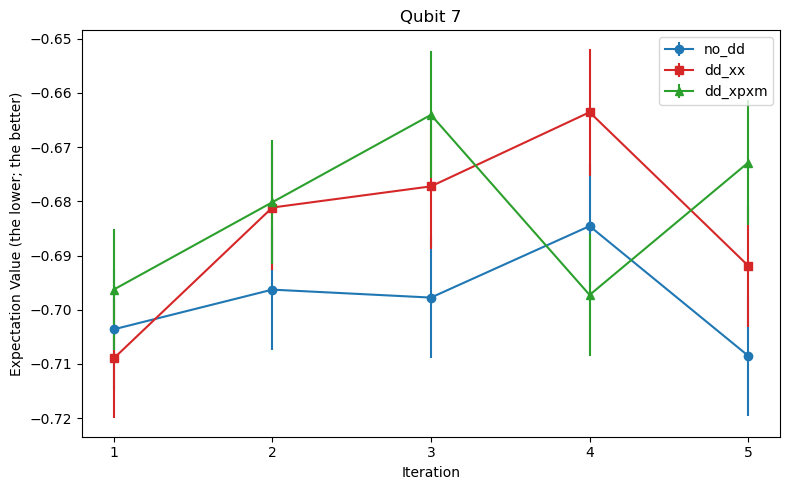

In [25]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 7

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the lower; the better)")

ax.errorbar(iterations, qubit_7["no_dd_evs"], yerr=qubit_7["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_7["dd_xx_evs"], yerr=qubit_7["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_7["dd_xpxm_evs"], yerr=qubit_7["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


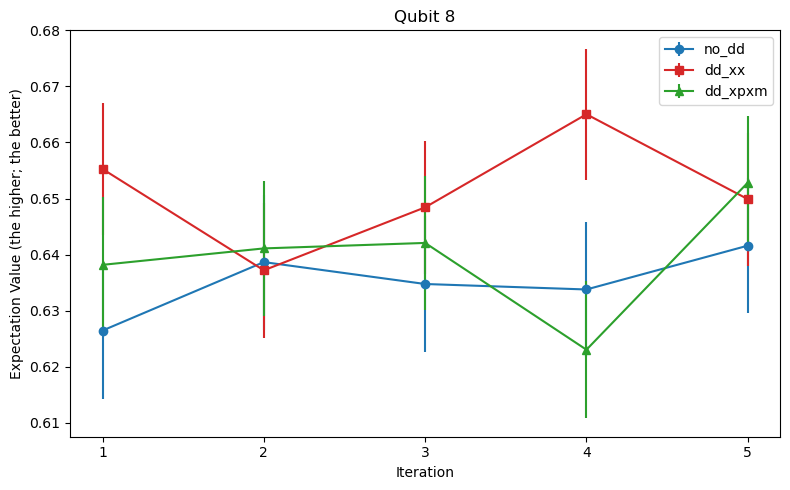

In [26]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 8

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the higher; the better)")

ax.errorbar(iterations, qubit_8["no_dd_evs"], yerr=qubit_8["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_8["dd_xx_evs"], yerr=qubit_8["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_8["dd_xpxm_evs"], yerr=qubit_8["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


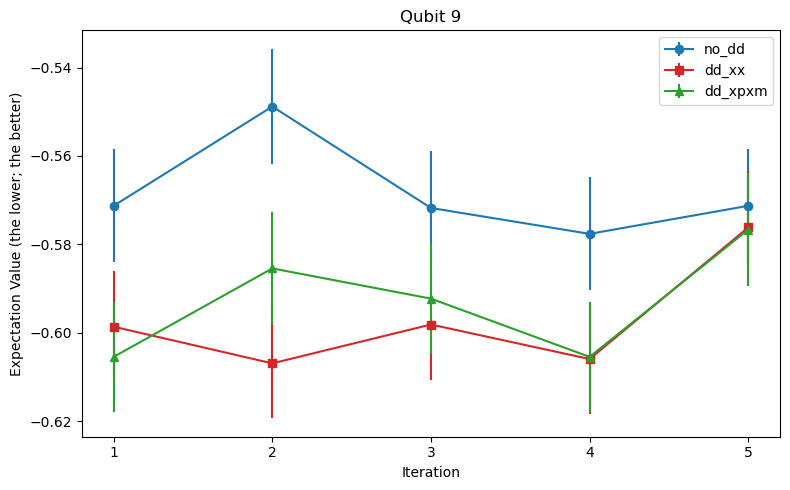

In [27]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 9

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the lower; the better)")

ax.errorbar(iterations, qubit_9["no_dd_evs"], yerr=qubit_9["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_9["dd_xx_evs"], yerr=qubit_9["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_9["dd_xpxm_evs"], yerr=qubit_9["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()


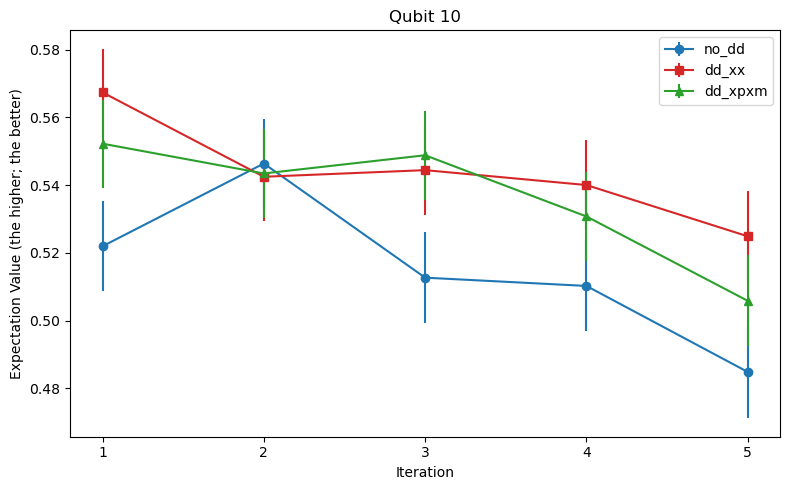

In [28]:
import numpy as np
import matplotlib.pyplot as plt

qubit = 10

# --- single qubit example (qubit 10) ---
iterations = np.arange(1, 5 + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"Qubit {qubit}")
ax.set_xticks(iterations)
ax.set_xlabel("Iteration")
ax.set_ylabel("Expectation Value (the higher; the better)")

ax.errorbar(iterations, qubit_10["no_dd_evs"], yerr=qubit_10["no_dd_std"], fmt='o-', color='#1f77b4', label='no_dd')
ax.errorbar(iterations, qubit_10["dd_xx_evs"], yerr=qubit_10["dd_xx_std"], fmt='s-', color='#d62728', label='dd_xx')
ax.errorbar(iterations, qubit_10["dd_xpxm_evs"], yerr=qubit_10["dd_xpxm_std"], fmt='^-', color='#2ca02c', label='dd_xpxm')
ax.legend()
plt.tight_layout()
plt.show()
